# XPROTO-ZK — Use-Case Tests: Consumer-Relative Freshness in ZooKeeper

**What this notebook shows.** A ZooKeeper client may read from any server, and a
follower answers from its own applied state, so a local read can be stale. This
notebook demonstrates, on a live 3-node ensemble, that *how stale* is a property
of **what the reader reads** (its footprint), not of the replica — and that a
small client-side change, `read_fresh(path, W)`, gives each reader exactly the
freshness it declares, witnessed by the `zxid`, at minimum cost.

Each section is a real ZooKeeper use case framed as a **test**: it prints its
numbers and `assert`s the expected behavior, so a clean run is a passing suite.

**Reproduce.** On a host with Docker: `bash lab_up.sh 200 60` (a 3-node
ZooKeeper 3.9 ensemble with a ~200 ms jittered lag induced on one follower's Zab
commit stream), then run this notebook, then `bash lab_down.sh`. It reads
`topology.json` written by `lab_up.sh`.


In [1]:
%matplotlib inline
import json, time, random, threading, bisect
from kazoo.client import KazooClient
import matplotlib.pyplot as plt

TOPO = json.load(open("topology.json"))
DELAY = TOPO["delay_ms"]                       # induced follower lag (ms)
lead = KazooClient(hosts=f"localhost:{TOPO['leader_port']}"); lead.start()
foll = KazooClient(hosts=f"localhost:{TOPO['follower_port']}"); foll.start()
print(f"ensemble up | leader :{TOPO['leader_port']} | delayed follower "
      f":{TOPO['follower_port']} | induced lag ~{DELAY} ms")

def ensure(paths):
    for p in paths:
        lead.ensure_path(p); lead.set(p, b"0")
    for _ in range(100):                       # wait for creates to reach the follower
        if all(foll.exists(p) for p in paths): break
        time.sleep(0.05)

def measure(footprint, write_hz, duration=4.0, policy="naive", tau=0.0):
    '''Drive `footprint` at `write_hz` writes/s through the leader; sample reads
    on the delayed follower under `policy`. Returns stale/sync/false-clear rates.
    read_fresh uses watermark W = the leader zxid as of (now - tau).'''
    stop = threading.Event(); lock = threading.Lock()
    wlog = {p: [] for p in footprint}          # per-znode applied write zxids
    def writer():
        interval = 1.0 / write_hz
        while not stop.is_set():
            p = random.choice(footprint)
            z = lead.set(p, str(random.random()).encode()).mzxid
            with lock: wlog[p].append(z)
            time.sleep(interval)
    buf_t, buf_z = [], []
    def sampler():
        while not stop.is_set():
            lead.get(footprint[0]); buf_t.append(time.time())
            buf_z.append(lead.last_zxid or 0); time.sleep(0.004)
    tw = threading.Thread(target=writer, daemon=True)
    ts = threading.Thread(target=sampler, daemon=True)
    tw.start(); ts.start(); time.sleep(0.6)    # let the lag build
    n = stale = sync = fcW = 0; end = time.time() + duration
    while time.time() < end:
        p = random.choice(footprint); now = time.time()
        lz = lead.get(p)[1].mzxid               # leader's latest version
        fmz = foll.get(p)[1].mzxid              # local follower read (version)
        fzx = foll.last_zxid or 0               # follower applied zxid (reply witness)
        n += 1
        if policy == "naive":
            if fmz < lz: stale += 1
        else:                                    # read_fresh
            k = bisect.bisect_right(buf_t, now - tau) - 1
            W = buf_z[k] if k >= 0 else 0
            if fzx >= W:                         # certified fresh locally
                with lock:
                    lst = wlog[p]; kk = bisect.bisect_right(lst, W) - 1
                    expected = lst[kk] if kk >= 0 else 0
                if fmz < expected: fcW += 1      # sound-witness check: must stay 0
            else:
                sync += 1; foll.sync(p); foll.get(p)
    stop.set(); tw.join(1); ts.join(1)
    return {"n": n, "naive_stale": stale / n if policy == "naive" else None,
            "sync_rate": sync / n if policy != "naive" else None,
            "false_clear_vs_W": fcW / n if policy != "naive" else None}


ensemble up | leader :2182 | delayed follower :2183 | induced lag ~200 ms


## Use case 1 — Configuration store (a **cold** footprint)

A service reads slowly-changing configuration znodes (a database URL, feature
flags). These are written rarely, so a follower is almost always caught up on
them. **Expectation:** a naive local read is essentially always fresh — for
config, local reads are fine.

In [2]:
config = [f"/uc/config/c{i}" for i in range(6)]   # a handful of rarely-written keys
ensure(config)
cfg = measure(config, write_hz=1.0, duration=5.0, policy="naive")  # each key ~every 6 s >> lag
print(f"config reader (cold footprint): naive stale rate = {cfg['naive_stale']:.3f}  (n={cfg['n']})")
assert cfg["naive_stale"] < 0.15, "config local reads should be nearly always fresh"
print("PASS: local reads are fine for a cold (config) footprint")

config reader (cold footprint): naive stale rate = 0.033  (n=1933)
PASS: local reads are fine for a cold (config) footprint


## Use case 2 — Service discovery / membership (a **hot** footprint)

A load balancer reads a rapidly-churning set of worker znodes (instances joining
and leaving). These are written constantly, so the delayed follower is almost
always behind on them. **Expectation:** the *same* follower that served config
freshly now false-clears the vast majority of local reads — staleness is a
property of the footprint, not the replica.

In [3]:
hot = [f"/uc/workers/w{i}" for i in range(6)]
ensure(hot)
disc = measure(hot, write_hz=80.0, policy="naive")
print(f"discovery reader (hot footprint): naive stale rate = {disc['naive_stale']:.3f}  (n={disc['n']})")
assert disc["naive_stale"] > 0.50, "hot local reads should be badly stale"
print("PASS: local reads are vacuous for a hot (discovery) footprint")

discovery reader (hot footprint): naive stale rate = 0.930  (n=1553)
PASS: local reads are vacuous for a hot (discovery) footprint


### The consumer-relativity punchline
Same follower, same instant, same induced lag — the false-clear rate differs by
**what the reader reads**. This is the crux of the result.

In [4]:
print(f"config  (cold) naive stale = {cfg['naive_stale']:.3f}")
print(f"discovery (hot) naive stale = {disc['naive_stale']:.3f}")
ratio = disc['naive_stale'] / max(cfg['naive_stale'], 1e-3)
print(f"-> {ratio:.0f}x difference from footprint alone, on the SAME follower")
assert disc['naive_stale'] > 5 * max(cfg['naive_stale'], 1e-3)
print("PASS: staleness is consumer-relative")

config  (cold) naive stale = 0.033
discovery (hot) naive stale = 0.930
-> 29x difference from footprint alone, on the SAME follower
PASS: staleness is consumer-relative


## Use case 3 — Bounded-staleness reader (the **fix**, tolerant)

A dashboard is happy with data "as of a fraction of a second ago." It declares a
tolerance `tau` equal to the follower's own lag and uses `read_fresh`, whose
watermark is the leader zxid as of `now - tau`. **Expectation:** it gets
guaranteed freshness-to-`tau` with almost no `sync()` calls — and the
`false_clear_vs_W` invariant is exactly 0 (the `zxid` is a sound witness).

In [5]:
bs = measure(hot, write_hz=80.0, policy="read_fresh", tau=DELAY/1000.0)
print(f"read_fresh @ tau={DELAY}ms (=lag): sync rate = {bs['sync_rate']:.3f}, "
      f"false_clear_vs_W = {bs['false_clear_vs_W']:.3f}  (n={bs['n']})")
assert bs["false_clear_vs_W"] == 0.0, "the zxid witness must be sound"
assert bs["sync_rate"] < 0.35, "a tolerant reader should rarely need sync()"
print("PASS: tolerant reader gets guaranteed freshness for almost no sync() cost")

read_fresh @ tau=200ms (=lag): sync rate = 0.156, false_clear_vs_W = 0.000  (n=90)
PASS: tolerant reader gets guaranteed freshness for almost no sync() cost


## Use case 4 — Leader / lock read (the **fix**, needs the latest)

Reading the current lock holder or elected leader must reflect the latest
committed state. The reader declares `tau=0`. **Expectation:** `read_fresh`
correctly falls to `sync()` on essentially every read (you *must* pay here) — but
it never false-clears, so correctness is not at the mercy of the footprint.

In [6]:
ll = measure(hot, write_hz=80.0, policy="read_fresh", tau=0.0)
print(f"read_fresh @ tau=0 (needs latest): sync rate = {ll['sync_rate']:.3f}, "
      f"false_clear_vs_W = {ll['false_clear_vs_W']:.3f}  (n={ll['n']})")
assert ll["false_clear_vs_W"] == 0.0
assert ll["sync_rate"] > 0.7, "a latest-needing reader must pay sync() on most reads"
print("PASS: latest-needing reader pays sync() -- and only it does, correctly")

read_fresh @ tau=0 (needs latest): sync rate = 1.000, false_clear_vs_W = 0.000  (n=13)
PASS: latest-needing reader pays sync() -- and only it does, correctly


## Summary — the freshness/cost curve

`read_fresh` lets each reader pick its point on a single curve: cost (sync rate)
equals the probability the follower's lag exceeds the reader's tolerance, while
the false-clear stays at zero throughout. The two blind endpoints are naive
(free, ~99% wrong) and `sync()`-always (1.0 cost, correct). The curve below is
the full sweep from `zk_fix.py`.

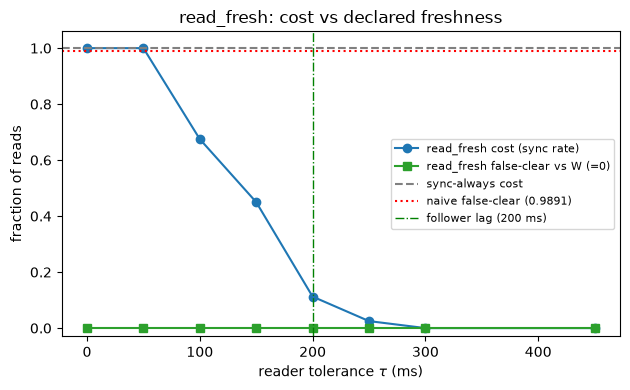

All use cases passed. Freshness is consumer-relative; the zxid is a sound witness;
read_fresh delivers each reader's declared freshness at minimum cost.


In [7]:
fix = json.load(open("ZK-FIX.json"))
rows = fix["read_fresh_sweep"]
xs = [r["tau_s"]*1000 for r in rows]
plt.figure(figsize=(6.4, 4.0))
plt.plot(xs, [r["sync_rate"] for r in rows], "o-", label="read_fresh cost (sync rate)")
plt.plot(xs, [r["false_clear_vs_W"] for r in rows], "s-", color="C2",
         label="read_fresh false-clear vs W (=0)")
plt.axhline(1.0, ls="--", c="grey", label="sync-always cost")
plt.axhline(fix["naive_false_clear_vs_latest"], ls=":", c="red",
            label=f"naive false-clear ({fix['naive_false_clear_vs_latest']})")
plt.axvline(DELAY, ls="-.", c="green", lw=1, label=f"follower lag ({DELAY} ms)")
plt.xlabel(r"reader tolerance $\tau$ (ms)"); plt.ylabel("fraction of reads")
plt.ylim(-0.03, 1.06); plt.legend(fontsize=8); plt.title("read_fresh: cost vs declared freshness")
plt.tight_layout(); plt.show()
print("All use cases passed. Freshness is consumer-relative; the zxid is a sound witness;")
print("read_fresh delivers each reader's declared freshness at minimum cost.")